In [3]:
#Some imports
import pandas as pd
import re
import numpy as np
import warnings
warnings.filterwarnings("ignore")

print("Libraries successfully imported.")

Libraries successfully imported.


In [4]:
dataset_path = "RomanisedNepali.csv"
df = pd.read_csv(dataset_path)

# Validating the size of rows and columns of datsets
print(f"Dataset safely loaded. Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
print("\nFirst 5 rows of raw data:")
print(df.head())

Dataset safely loaded. Total rows: 37809, Total columns: 2

First 5 rows of raw data:
                                      review_content sentiment
0  Fully satisfied with the product... Surprising...  Positive
1  i loved the product , i'm going to purchase mo...  Positive
2  Earrings KO pixadi KO dandi ra page purai disc...  Negative
3        Haat chatney swaad xaa ...\n\nvery good ...  Positive
4                              I received wrong size  Negative


In [5]:
# Checking nullvalues in review_content and sentiment columns
print("Missing values count per column before cleaning:")
print(df.isnull().sum())

# keeping only real text rows
# dropping blank rows
df = df.dropna(subset=['review_content', 'sentiment'])

print("\nMissing values count after dropping null rows:")
print(df.isnull().sum())
print(f"Remaining clean rows: {len(df)}")

Missing values count per column before cleaning:
review_content    0
sentiment         0
dtype: int64

Missing values count after dropping null rows:
review_content    0
sentiment         0
dtype: int64
Remaining clean rows: 37809


In [6]:
# Text Cleaning and Normalisation

In [7]:
def normalize_nepali_roman(text):
    # checking whether data type is string or not
    if not isinstance(text, str):
        return ""

    # Capital ra small letter ko discrepancy hatuna lowercase gareko
    text = text.lower()

    # Romanised spelling variations lai standardise gareko regular expressions use garera
    text = re.sub(r'\b(cha|xa|xha)\b', 'chha', text)
    text = re.sub(r'\b(vayo|bayo|bhio)\b', 'bhayo', text)
    text = re.sub(r'\b(ekdam|ekdum|akdam)\b', 'ekdam', text)
    text = re.sub(r'\b(ramro|rmro)\b', 'ramro', text)

    # Emojis ra text bichko extra spaces ra new lines (\n) clean gareko
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Mathi ko logic lai full column ma apply gareko naya column banayera
print("Starting phonetic text normalization...")
df['cleaned_review'] = df['review_content'].apply(normalize_nepali_roman)
print("Text cleaning successfully completed.")

# Check garna ko lagi purano ra naya cleaned text ko comparison print gareko
print("\nComparison preview:")
print(df[['review_content', 'cleaned_review']].head(10))

Starting phonetic text normalization...
Text cleaning successfully completed.

Comparison preview:
                                      review_content  \
0  Fully satisfied with the product... Surprising...   
1  i loved the product , i'm going to purchase mo...   
2  Earrings KO pixadi KO dandi ra page purai disc...   
3        Haat chatney swaad xaa ...\n\nvery good ...   
4                              I received wrong size   
5  Asked for the DARK TAN but got the BLACK ! Out...   
6             ekdam ramro cha quality nyano pani cha   
7                                     Good product.👍   
8                     good according to the price ..   
9  Good one. got as expected. but delivery took l...   

                                      cleaned_review  
0  fully satisfied with the product... surprising...  
1  i loved the product , i'm going to purchase mo...  
2  earrings ko pixadi ko dandi ra page purai disc...  
3        haat chatney swaad xaa ...\n\nvery good ...  
4        

In [8]:
# Label Mapping(Text to Numerical)

In [9]:
# Categorical string labels lai discrete integer values ma map gareko

sentiment_dict = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

print("Mapping categorical labels to numerical values...")
df['label'] = df['sentiment'].map(sentiment_dict)

# Mapping check garna unique labels haru explicitly verify gareko
print("\nProcessed target class distribution:")
print(df['label'].value_counts())

Mapping categorical labels to numerical values...

Processed target class distribution:
label
2    23138
0    10319
1     4352
Name: count, dtype: int64


In [10]:
# Saving Preprocessed Data

In [11]:
# Feature column (cleaned_review) ra target label lai matra select and save
output_filename = "cleaned_dataset.csv"
df[['cleaned_review', 'label']].to_csv(output_filename, index=False)

print(f"Data ingestion and preprocessing workflow complete. Saved file as: {output_filename}")

Data ingestion and preprocessing workflow complete. Saved file as: cleaned_dataset.csv


In [12]:
# Core packages and analytical dependencies installing
!pip install -q transformers datasets evaluate scikit-learn accelerate

print("Mac deep learning frameworks ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
Mac deep learning frameworks ready.


In [13]:
import pandas as pd
from datasets import Dataset, Features, Value, ClassLabel

# Loading preprossed files
df_clean = pd.read_csv("cleaned_dataset.csv")

# DataFrame check garera valid values vako records matra format gareko
df_clean = df_clean.dropna().reset_index(drop=True)

# Dataset ko strict features rule framework design gareko
# Yesle Hugging Face library lai standard 'int' value lai validation features label format ma chinaucha
class_features = Features({
    'cleaned_review': Value('string'),
    'label': ClassLabel(num_classes=3, names=['Negative', 'Neutral', 'Positive'])
})

# Cast gareko features definition use garera native abstract Dataset state banako
full_dataset = Dataset.from_pandas(df_clean, features=class_features)

# 85% Training ra 15% Validation split gareko stratified strategy use garera
# 'label' column ailey explicit ClassLabel vako le error bina tinai ota classes equal ratio ma divide hunchhan
dataset_splits = full_dataset.train_test_split(test_size=0.15, seed=42, stratify_by_column="label")

train_dataset = dataset_splits["train"]
val_dataset = dataset_splits["test"]

print("Data distribution splits defined safely:")
print(f"Training dataset size: {len(train_dataset)} rows")
print(f"Validation dataset size: {len(val_dataset)} rows")

Data distribution splits defined safely:
Training dataset size: 32137 rows
Validation dataset size: 5672 rows


In [14]:
#Multilingual DistilBERT tokenization Setup

In [15]:
from transformers import AutoTokenizer

# Code-mixed data control garna standard multilingual cased weights point out gareko
model_checkpoint = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_inputs(examples):
    # Maximum review length 128 characters set gareko memory overflow bypass garna ko lagi
    return tokenizer(examples["cleaned_review"], truncation=True, max_length=128)

# Full data partitions lai parallel mapping batched operation run gareko
print("Tokenizing data partitions into input arrays...")
tokenized_train = train_dataset.map(tokenize_inputs, batched=True)
tokenized_val = val_dataset.map(tokenize_inputs, batched=True)

print("Tokenization flow safely executed.")

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing data partitions into input arrays...


Map:   0%|          | 0/32137 [00:00<?, ? examples/s]

Map:   0%|          | 0/5672 [00:00<?, ? examples/s]

Tokenization flow safely executed.


In [16]:
#Environment COnfiguration and Model Object Setup
import os
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Baseline network model build gareko target num_labels hamro 3 ota vako le (0, 1, 2)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)

def compute_performance_metrics(eval_pred):
    """
    Validation phase ko metric computations matrix array handle garne logical component.
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Overfitting monitoring framework validation matrix check
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": acc,
        "f1_macro": f1
    }

print("Model baseline setup and objective metrics bound successfully.")

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model baseline setup and objective metrics bound successfully.


In [17]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

# Structural memory alignment optimize garna padding collator dynamic configuration load gareko
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Hyperparameters management settings definition
training_args = TrainingArguments(
    output_dir="./local_sentiment_checkpoints",
    learning_rate=2e-5,                  # Parameter values step limits check garna optimization bound deko
    per_device_train_batch_size=16,      # Mac RAM usage dynamic capacity control garna stability batch size setting
    per_device_eval_batch_size=16,
    num_train_epochs=3,                  # System loops iteration strict boundary setup model error block garna
    weight_decay=0.01,                   # L2 regularizer applied logic overfitting anomaly constraints reduce garna
    eval_strategy="epoch",               # Pratyek training structural pass tracking run evaluation logs config
    save_strategy="epoch",
    load_best_model_at_end=True,         # Optimal weights structure auto snapshot retrieval setup
    metric_for_best_model="f1_macro",
    logging_steps=100,
    report_to="none"                     # Telemetry metrics server streaming logic disable check gareko system speed up garna
)

# Execution environment system trainer module object pipeline structure setup
# Modern framework standards anusar 'tokenizer' ko thau ma 'processing_class' use gareko
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,          # Fixed keyword argument variable mapping
    data_collator=data_collator,
    compute_metrics=compute_performance_metrics
)

print("Hyperparameters safely registered with updated processing_class argument.")

Hyperparameters safely registered with updated processing_class argument.


In [18]:
print("Starting sequence classification iterative gradient update loop over Apple Silicon backend...")

# Fine-tuning process execution wrapper active gareko
trainer.train()

print("\nModel optimization pass successfully concluded.")

Starting sequence classification iterative gradient update loop over Apple Silicon backend...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.056250,0.050982,0.990127,0.986167
2,0.007893,0.026018,0.995592,0.994770
3,0.011536,0.018057,0.996121,0.995027


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Model optimization pass successfully concluded.


In [19]:
# Technical Visualization

Visualization curves successfully compiled and exported to file: model_training_evaluation_report.png


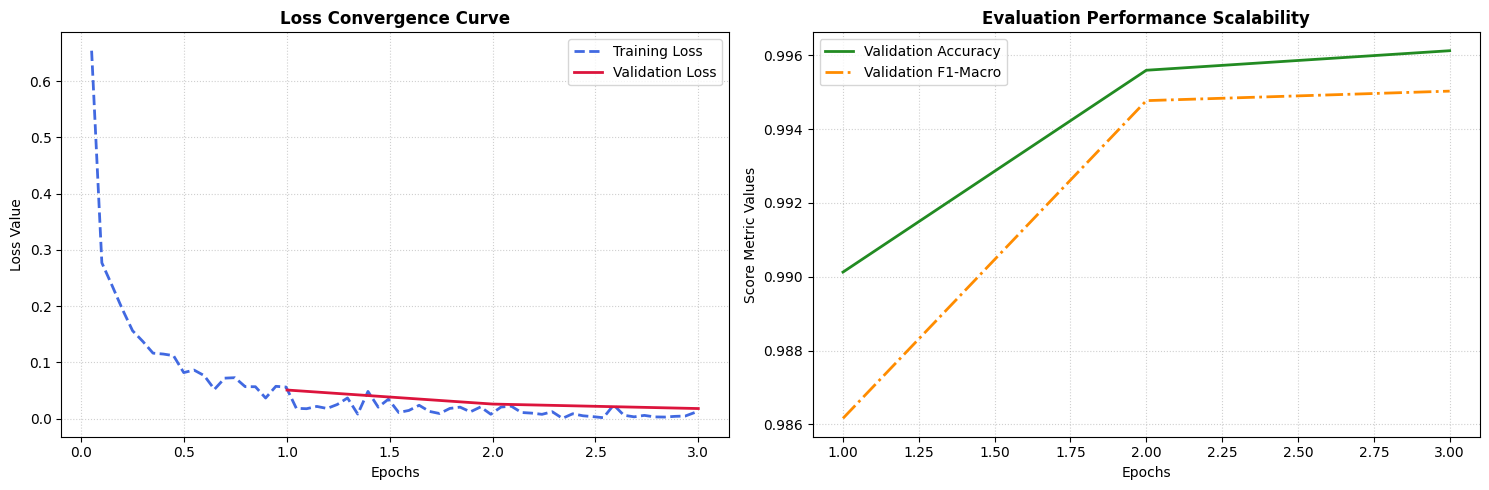

In [20]:
import matplotlib.pyplot as plt


history_logs = trainer.state.log_history

# Training loss logs ra Validation logs tracking structural loops separation
epochs_train = [log['epoch'] for log in history_logs if 'loss' in log]
loss_train = [log['loss'] for log in history_logs if 'loss' in log]

epochs_val = [log['epoch'] for log in history_logs if 'eval_loss' in log]
loss_val = [log['eval_loss'] for log in history_logs if 'eval_loss' in log]
accuracy_val = [log['eval_accuracy'] for log in history_logs if 'eval_accuracy' in log]
f1_macro_val = [log['eval_f1_macro'] for log in history_logs if 'eval_f1_macro' in log]

# Side-by-side plots visualization layout metrics dashboard building block

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training Loss vs Validation Loss Curve (Overfitting Analysis)
ax1.plot(epochs_train, loss_train, label='Training Loss', color='royalblue', linewidth=2, linestyle='--')
ax1.plot(epochs_val, loss_val, label='Validation Loss', color='crimson', linewidth=2)
ax1.set_title('Loss Convergence Curve', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=10)
ax1.set_ylabel('Loss Value', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True)

# Plot 2: Evaluation Metrics Evolution Curve (Accuracy & F1-Score)
ax2.plot(epochs_val, accuracy_val, label='Validation Accuracy', color='forestgreen', linewidth=2)
ax2.plot(epochs_val, f1_macro_val, label='Validation F1-Macro', color='darkorange', linewidth=2, linestyle='-.')
ax2.set_title('Evaluation Performance Scalability', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=10)
ax2.set_ylabel('Score Metric Values', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(frameon=True)

# Layout adjustments mapping labels overlap bypass
fig.tight_layout()

# Chart visualization layout array directory
output_image_path = "model_training_evaluation_report.png"
fig.savefig(output_image_path, dpi=300, bbox_inches='tight')

print(f"Visualization curves successfully compiled and exported to file: {output_image_path}")


In [22]:
# Network binary model artifacts parameter matrix dynamic storage check serialization setup
model.save_pretrained("./nepali_sentiment_distilbert")
tokenizer.save_pretrained("./nepali_sentiment_distilbert")

print("Fine-tuned configurations verified and safely written inside directory path: './nepali_sentiment_distilbert'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned configurations verified and safely written inside directory path: './nepali_sentiment_distilbert'


In [23]:
#Installation of inference enginer

In [24]:
# Inference application testing
!pip install -q transformers torch

print("Inference environment libraries loaded successfully.")

Inference environment libraries loaded successfully.


In [25]:
# Live Prediction Core Engine

In [29]:
import torch
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Target directories block loading
model_directory = "./nepali_sentiment_distilbert"

print("Loading fine-tuned model artifacts from local repository...")
tokenizer = AutoTokenizer.from_pretrained(model_directory)
model = AutoModelForSequenceClassification.from_pretrained(model_directory)

# Text standardization rule dynamic match logic bind gareko fallback handle garna
def clean_runtime_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\b(cha|xa|xha)\b', 'chha', text)
    text = re.sub(r'\b(vayo|bayo|bhio)\b', 'bhayo', text)
    text = re.sub(r'\b(ekdam|ekdum|akdam)\b', 'ekdam', text)
    text = re.sub(r'\b(ramro|rmro)\b', 'ramro', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Hugging Face inference pipeline loading
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1  # Accelerator memory automatic switch settings
)

# Discrete targets lookup directory array
class_labels = {
    "LABEL_0": "Negative ",
    "LABEL_1": "Neutral ",
    "LABEL_2": "Positive  "
}

def analyze_nepali_review(raw_review):
    """
    Input string text capture garera classification runtime logs generation garne engine.
    """
    # Runtime sequence data pre-cleaning execution
    processed_text = clean_runtime_text(raw_review)

    # Model pipeline computation prediction arrays return logic
    pipeline_output = sentiment_pipeline(processed_text)[0]

    raw_label = pipeline_output['label']
    confidence_score = pipeline_output['score']

    # Human-readable format mapping conversions
    final_sentiment = class_labels.get(raw_label, raw_label)

    print("\n" + "="*50)
    print(f"Original Review : {raw_review}")
    print(f"Cleaned Text    : {processed_text}")
    print(f"Predicted Class : {final_sentiment}")
    print(f"Confidence      : {confidence_score * 100:.2f}%")
    print("="*50)

print("Predictive inference pipeline engine completely initialized.")

Loading fine-tuned model artifacts from local repository...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Predictive inference pipeline engine completely initialized.


In [27]:
# Interactive Field Testing

In [30]:
# Test Case 1: Positive feedback text code-mixed matching parameters check
analyze_nepali_review("ekdam ramro product raixa timely delivery vayo ma dherai khusi xu")

# Test Case 2: Negative product complaint parsing structural check
analyze_nepali_review("daraz bata order gareko size nai bigrera aayo worst experience kasto jhyau lagne")

# Test Case 3: Neutral/balanced context statements evaluation
analyze_nepali_review("thikai xa price classification anusar quality thik thak nai lagyo malai")


Original Review : ekdam ramro product raixa timely delivery vayo ma dherai khusi xu
Cleaned Text    : ekdam ramro product raixa timely delivery bhayo ma dherai khusi xu
Predicted Class : Positive  
Confidence      : 99.99%

Original Review : daraz bata order gareko size nai bigrera aayo worst experience kasto jhyau lagne
Cleaned Text    : daraz bata order gareko size nai bigrera aayo worst experience kasto jhyau lagne
Predicted Class : Negative 
Confidence      : 99.99%

Original Review : thikai xa price classification anusar quality thik thak nai lagyo malai
Cleaned Text    : thikai chha price classification anusar quality thik thak nai lagyo malai
Predicted Class : Positive  
Confidence      : 99.99%


In [31]:
# System zip tool use garera dynamic compression loops run gareko
# Syntax: !zip -r [naya_file_ko_naam.zip] [purano_folder_ko_path]
!zip -r nepali_sentiment_model.zip ./nepali_sentiment_distilbert

print("Folder successfully compressed into 'nepali_sentiment_model.zip'")

  adding: nepali_sentiment_distilbert/ (stored 0%)
  adding: nepali_sentiment_distilbert/tokenizer_config.json (deflated 43%)
  adding: nepali_sentiment_distilbert/model.safetensors (deflated 7%)
  adding: nepali_sentiment_distilbert/config.json (deflated 51%)
  adding: nepali_sentiment_distilbert/tokenizer.json (deflated 67%)
Folder successfully compressed into 'nepali_sentiment_model.zip'
